In [1]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import polars as pl
import sys

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
rep1_s = "~/Dokument/fragments/nanoCT_rep1_fragments"
rep2_s = "~/Dokument/fragments/nanoCT_rep2_fragments"

dm6 = scit.tl.get_genome_dict('DM6')
rep1ac = scit.ld.fragments(
    f"{rep1_s}/emb14_16/H3K27ac_ACTCCAGA/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)
rep2ac = scit.ld.fragments(
    f"{rep2_s}/droso_emb_14_16/H3K27ac_ATAGAGGC/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)


Info: Reading fragments file with 2687808 lines...
Info: Number of unique barcodes is 57506...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022280328' 'chrUnmapped_Scaffold_8_D1580_D1567'
 'chrmitochondrion_genome']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:11<00:00, 19.47it/s]


Info: Reading fragments file with 1949255 lines...
Info: Number of unique barcodes is 41318...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022280328' 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:09<00:00, 24.40it/s]


In [ ]:
rep1me = scit.ld.fragments(
    f"{rep1_s}/emb14_16/H3K27me3_GTAGTCCA/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)
rep2me = scit.ld.fragments(
    f"{rep2_s}/droso_emb_14_16/H3K27me3/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)


Info: Reading fragments file with 1869566 lines...
Info: Number of unique barcodes is 48116...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022280328' 'chrUnmapped_Scaffold_8_D1580_D1567'
 'chrmitochondrion_genome']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:08<00:00, 26.30it/s]


Info: Reading fragments file with 1409707 lines...
Info: Number of unique barcodes is 32031...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022280328' 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:06<00:00, 35.02it/s]


In [ ]:
# Stack datas into one AnnData
rep1 = scit.tl.stack_adata([rep1ac, rep1me], ['acet', 'meth'])
rep2 = scit.tl.stack_adata([rep2ac, rep2me], ['acet', 'meth'])
rep1.write_h5ad('private/data/clean_method/late_rep1.h5ad')
rep2.write_h5ad('private/data/clean_method/late_rep2.h5ad')

Info: found 22465 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


Info: found 11166 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


In [2]:
rep1 = ad.read_h5ad('private/data/clean_method/late_rep1.h5ad')
rep2 = ad.read_h5ad('private/data/clean_method/late_rep2.h5ad')

Info: Added acet counts metadata
Info: Added meth counts metadata
Info: Added acet counts metadata
Info: Added meth counts metadata


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


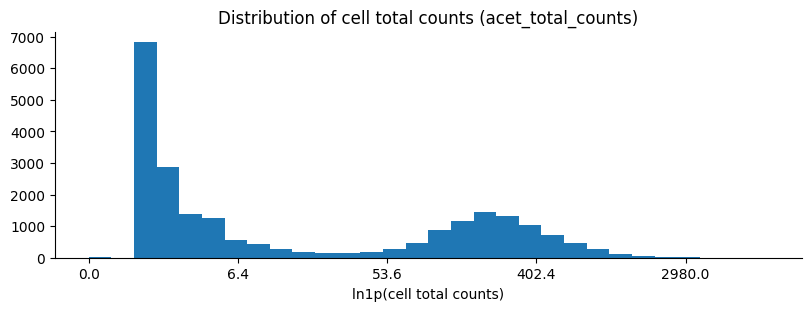

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


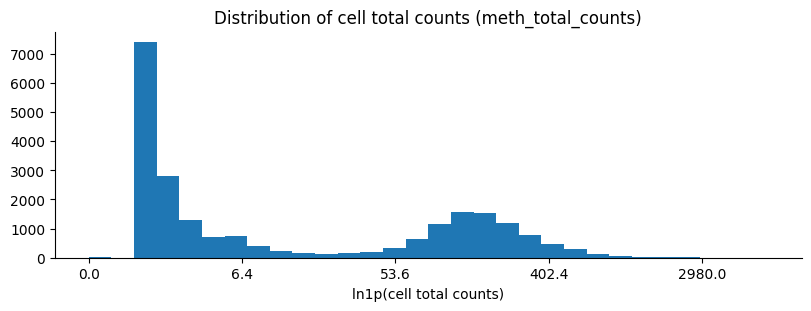

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


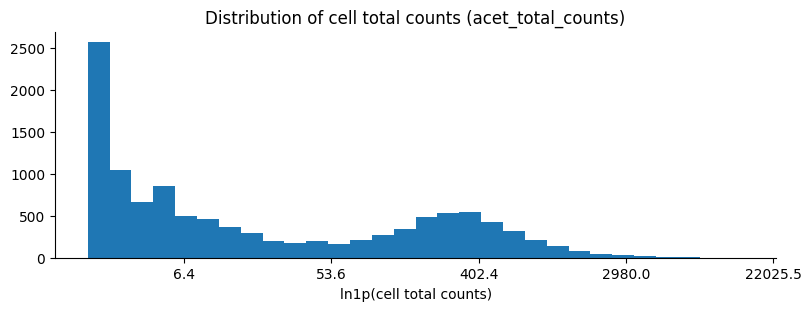

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


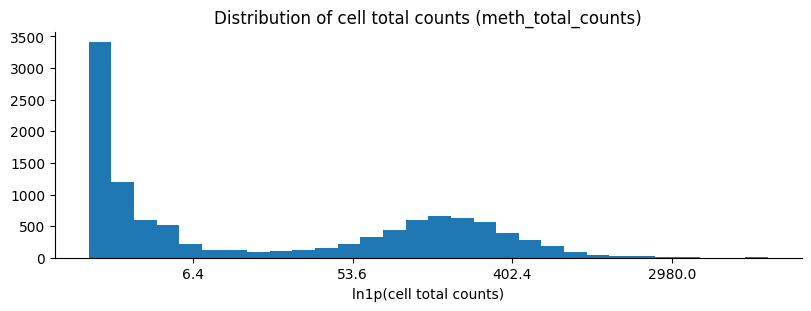

In [3]:
scit.tl.add_metadata(rep1, ['acet', 'meth'])
scit.tl.add_metadata(rep2, ['acet', 'meth'])
scit.set_defaults(figsize=(8,3))
scit.pl.counts_histogram(rep1, label_exp=True)
scit.pl.counts_histogram(rep2, label_exp=True)

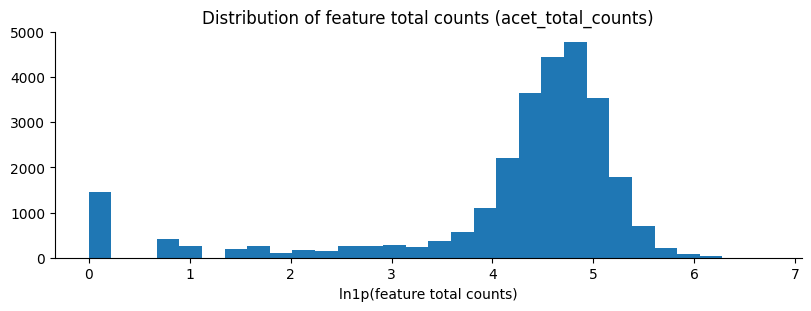

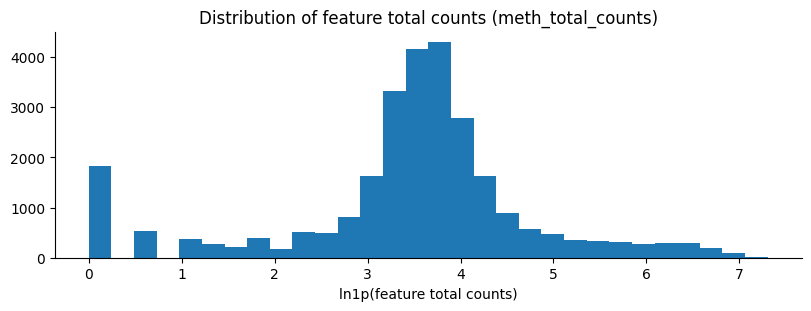

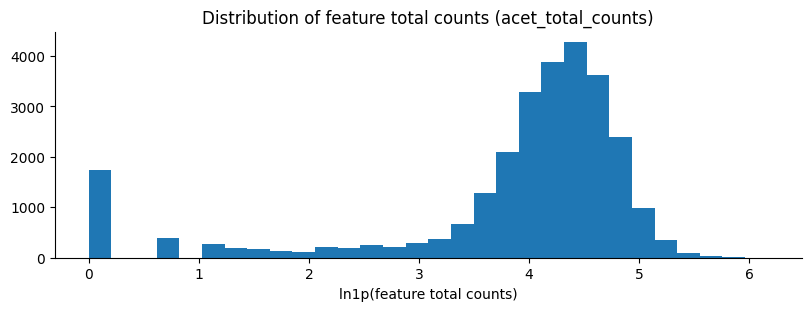

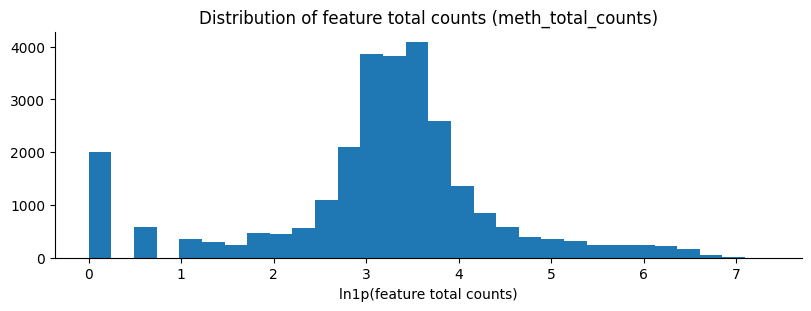

In [4]:
scit.pl.counts_histogram(rep1, hist_type='feature')
scit.pl.counts_histogram(rep2, hist_type='feature')

In [5]:
rep1 = scit.tl.filter(
    rep1, ['acet', 'meth'], 
    min_obs_counts=[40, 40], 
    max_obs_counts=[99j, 99j], 
    return_purged=True
)
rep2 = scit.tl.filter(
    rep2, ['acet', 'meth'], 
    min_obs_counts=[40, 40], 
    max_obs_counts=[99j, 99j], 
    return_purged=True
)

Info: The 99.0th percentile of obs total counts is 1096.0
Info: The 99.0th percentile of obs total counts is 716.0800000000017
Info: The 99.0th percentile of obs total counts is 1863.3500000000004
Info: The 99.0th percentile of obs total counts is 1150.7000000000007


Info: Added acet counts metadata
Info: Added meth counts metadata
Info: Added acet counts metadata
Info: Added meth counts metadata


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


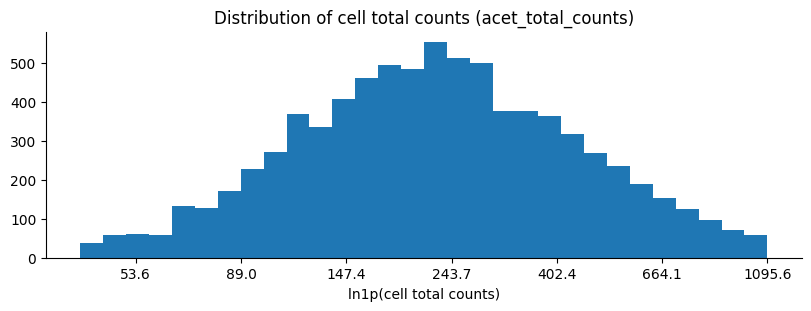

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


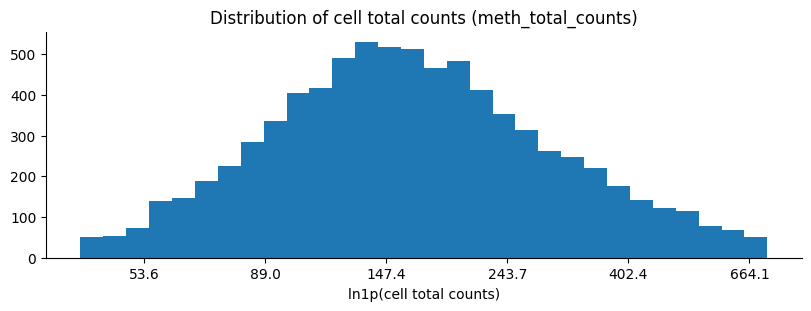

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


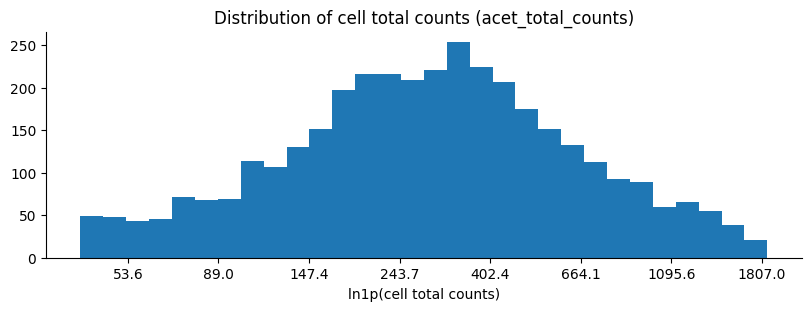

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


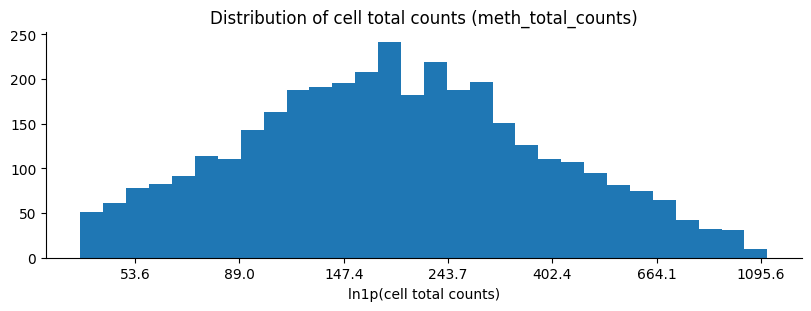

In [6]:
scit.tl.add_metadata(rep1, ['acet', 'meth'])
scit.tl.add_metadata(rep2, ['acet', 'meth'])
scit.set_defaults(figsize=(8,3))
scit.pl.counts_histogram(rep1, label_exp=True)
scit.pl.counts_histogram(rep2, label_exp=True)

In [7]:
assert np.unique([n[-1] for n in rep1.obs_names]).shape[0] == 1
assert np.unique([n[-1] for n in rep2.obs_names]).shape[0] == 1

rep1.obs['batch'] = 'batch1'
rep1.obs_names = [f"{n[:-2]}-l1" for n in rep1.obs_names]
rep2.obs_names = [f"{n[:-2]}-l2" for n in rep2.obs_names]
rep2.obs['batch'] = 'batch2'

# Same var
assert rep2.shape[1] == np.intersect1d(rep2.var_names, rep1.var_names).shape[0]

In [8]:
adata = ad.concat([rep1, rep2])
assert (adata.var_names == rep1.var_names).all()
import pandas as pd
adata.obs['batch'] = pd.Categorical(adata.obs['batch'])
adata.obs['timep'] = '14_16h'
adata.obs['timep'] = pd.Categorical(adata.obs['timep'])
adata.var = rep1.var.copy()
scit.tl.add_metadata(adata, ['acet', 'meth'])

Info: Added acet counts metadata
Info: Added meth counts metadata


In [9]:
adata=scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[1, 1], return_purged=True
)

In [10]:
# Soft filter
scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[15, 15]
)

Info: Adata not modified. If you want to remove excluded cells and bins, use return_purged = True or remove them manually


In [11]:
layers = ['acet', 'meth']
layer_keys = ['X_acetylation', 'X_methylation']
scit.set_defaults(figsize=(12,5))

for i in range(len(layers)):
    print(scit.em.spectral(adata, layers[i]))
    adata.obsm[layer_keys[i]] = adata.obsm['X_spectral'].copy()
    del adata.obsm['X_spectral']
    scit.tl.remove_pc(adata, layer_keys[i], 0)

[1.         0.07111909 0.03744227 0.02194291 0.01878566 0.01831581
 0.01809876 0.01790092 0.01779266 0.01761754 0.01756267 0.01753903
 0.01751545 0.01747455 0.01745552 0.01737837 0.017323   0.0172961
 0.01727501 0.01719898 0.01717585 0.01714985 0.01713635 0.01710285
 0.01708597]
[1.         0.0795386  0.04461787 0.03384317 0.03247395 0.02759248
 0.02516146 0.02318778 0.02236737 0.0215262  0.02073612 0.02052357
 0.02050146 0.02036094 0.02032636 0.02023935 0.02015649 0.02006075
 0.02002483 0.02001307 0.01992593 0.01982378 0.01981834 0.01975832
 0.01973254]


In [12]:
np.random.seed(0)
print(scit.em.multiview_spectral(adata, ['acet', 'meth'], random_seed=22))

[1.         0.06880725 0.03489422 0.02811308 0.0228153  0.01747931
 0.01595436 0.01503336 0.01433532 0.01254346 0.01239034 0.01230484
 0.01212048 0.01208199 0.01199341 0.01193725 0.01187918 0.01185245
 0.01184605 0.01180257 0.01178692 0.0117463  0.01171744 0.01170012
 0.01168211]


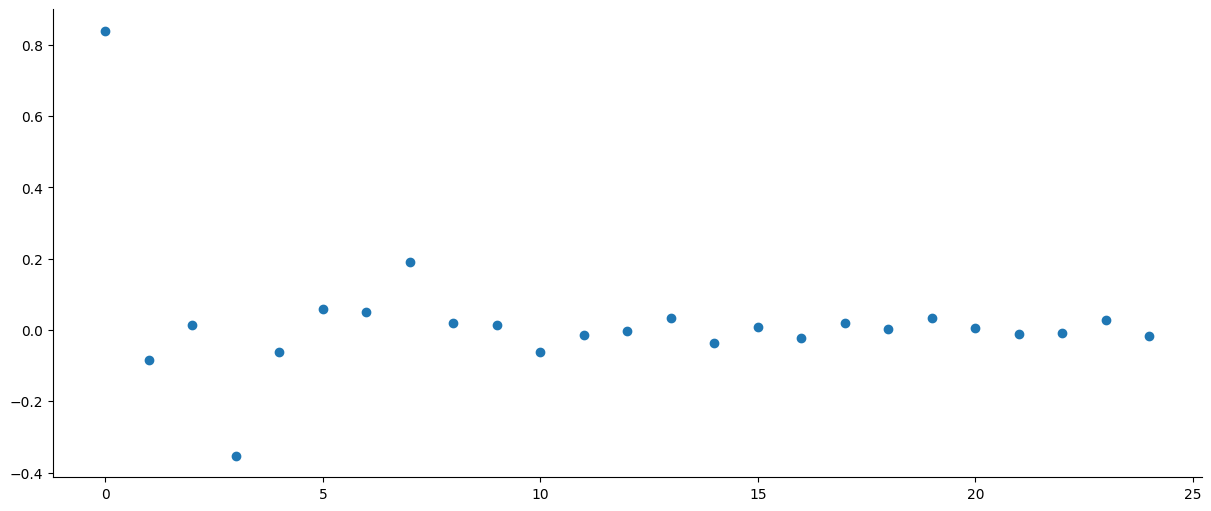

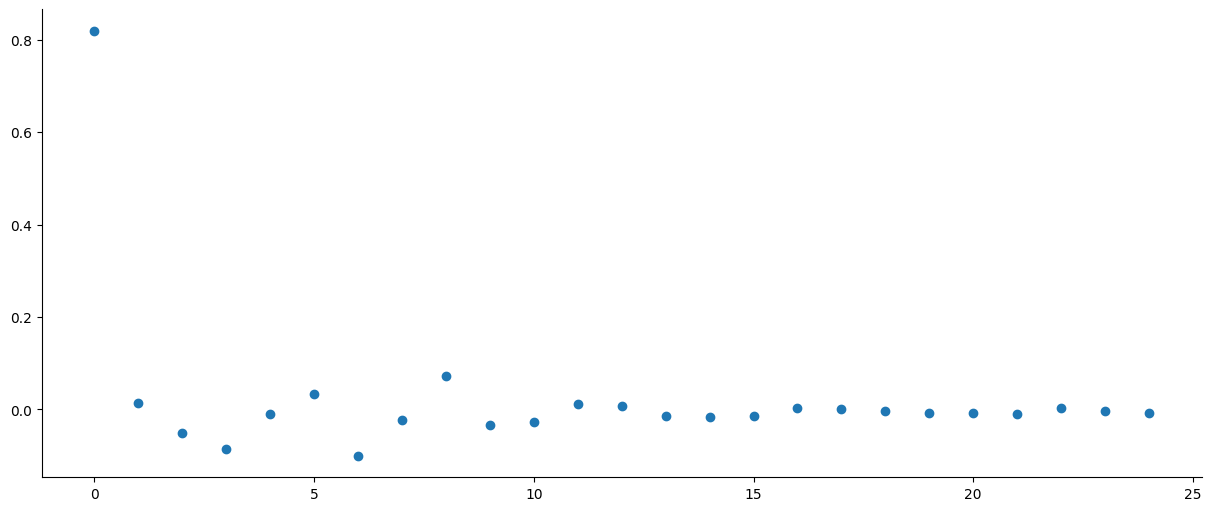

In [13]:
scit.pl.depth_corr(adata, 'X_multi_spectral', 'acet')
scit.pl.depth_corr(adata, 'X_multi_spectral', 'meth')

In [14]:
scit.tl.remove_pc(adata, 'X_multi_spectral', 0)

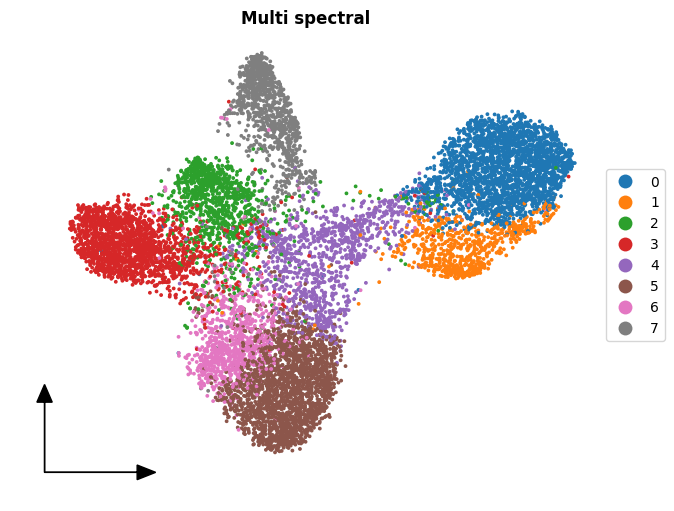

In [ ]:
scit.em.umap(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.leiden(adata, 1, obsp_key='connectivities')
scit.set_defaults(figsize=(6,5))scit.pl.depth_corr(adata, 'X_multi_spectral', 'acet')
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral')

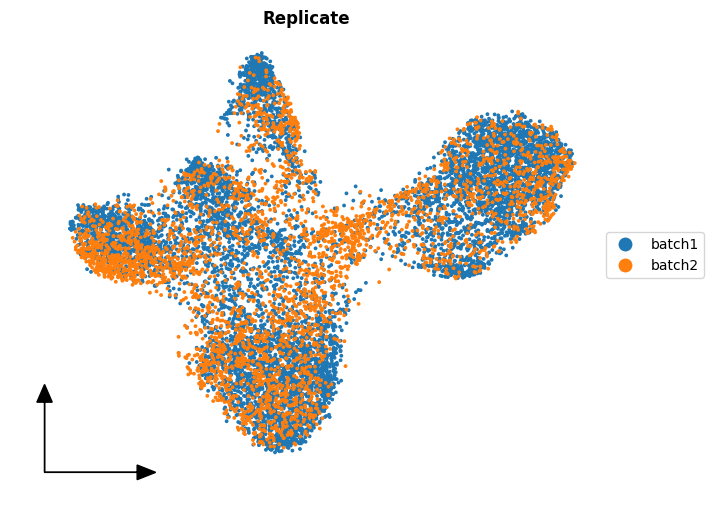

In [16]:
scit.pl.embedding2d(adata, 'X_umap', 'batch', title=f'Replicate')

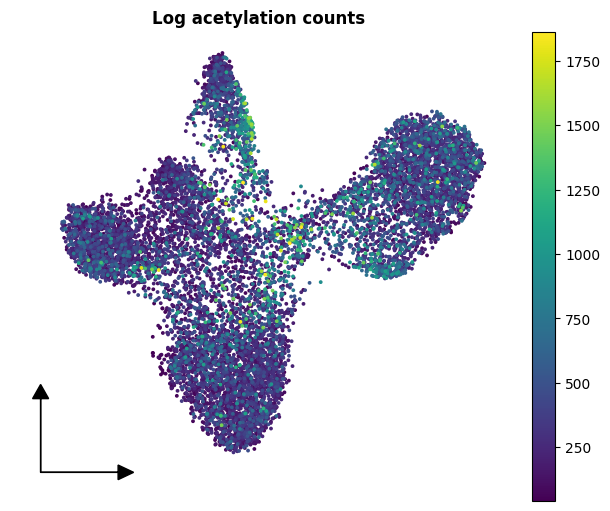

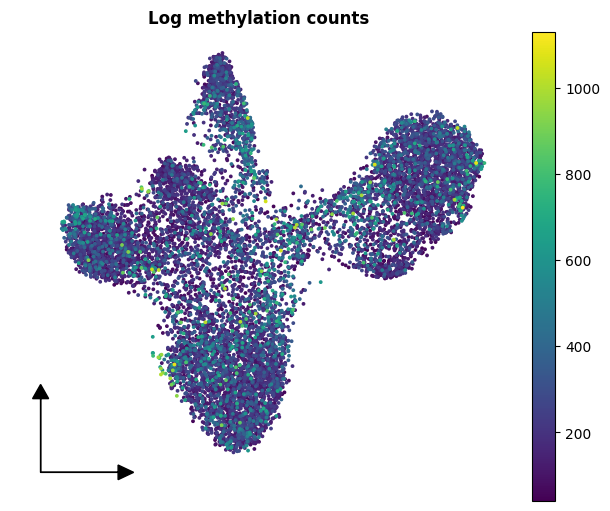

In [17]:
scit.pl.embedding2d(adata, 'X_umap', 'acet_total_counts', title='Log acetylation counts')
scit.pl.embedding2d(adata, 'X_umap', 'meth_total_counts', title='Log methylation counts')

In [18]:
adata.write_h5ad('private/data/clean_method/late.h5ad')